## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

---

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.




In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.columns = (
    df.columns
      .str.strip()        
      .str.lower()          
      .str.replace(" ", "_")
      .str.replace("-", "_")
)
df.head()

,uid,asin,title,stars,reviews,price,isbestseller,boughtinlastmonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [10]:
#Crosstab Analysis
ct = pd.crosstab(df["category"], df["isbestseller"])
ct


isbestseller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [11]:
# Proporción de True dentro de cada categoría
best_share = ct.div(ct.sum(axis=1), axis=0)[True].sort_values(ascending=False)
best_share.head(20)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Mirrors                           0.028000
Wind Instruments                  0.028000
Professional Medical Supplies     0.027344
PC & Video Games                  0.025466
Bakeware                          0.025105
Material Handling Products        0.025000
Bedding Accessories               0.024390
Tableware                         0.024096
Arts & Crafts                     0.024086
Baby                              0.022658
Lighting                          0.022556
Window Treatments                 0.020921
Name: True, dtype: float64

In [18]:
#Statistical Tests
 
#Chi-Squared Test
from scipy.stats import chi2_contingency            

chi2, p, dof, expected = chi2_contingency(ct)
chi2, p, dof
#Interpretation
alpha = 0.05  

print(f"P-valor = {p:.3f}")
if p < alpha:
    print("Rechazamos la hipótesis nula: existe una relación significativa entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no existe una relación significativa entre las variables.") 

#Kramer's V
n = ct.sum().sum()
k = min(ct.shape) - 1   
kramers_v = np.sqrt(chi2 / (n * k))
kramers_v   
#Interpretation of Kramer's V
print(f"Kramér’s V = {kramers_v:.3f}")
if kramers_v < 0.1:
    print("La asociación entre las variables es débil.")    
elif 0.1 <= kramers_v < 0.3:
    print("La asociación entre las variables es moderada.")
else:
    print("La asociación entre las variables es fuerte.")


P-valor = 0.000
Rechazamos la hipótesis nula: existe una relación significativa entre las variables.
Kramér’s V = 0.122
La asociación entre las variables es moderada.


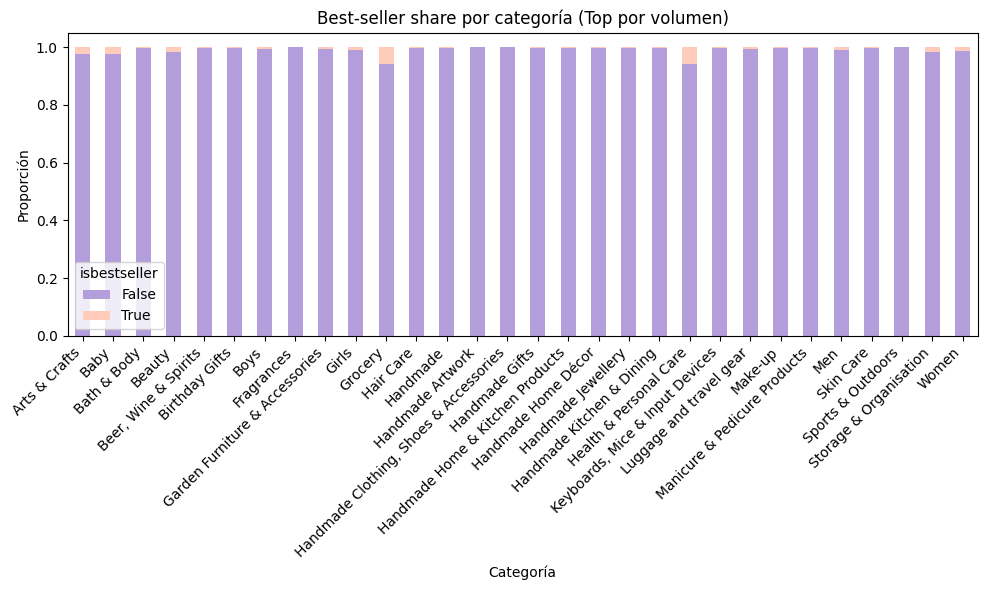

In [37]:
import matplotlib.pyplot as plt

topN = 30
top_cats = df["category"].value_counts().head(topN).index

ct_top = pd.crosstab(
    df.loc[df["category"].isin(top_cats), "category"],
    df.loc[df["category"].isin(top_cats), "isbestseller"]
)

ct_top_norm = ct_top.div(ct_top.sum(axis=1), axis=0)

ax = ct_top_norm.plot(kind="bar", stacked=True, figsize=(10, 6), color=["#B39DDB", "#FFCCBC"])
ax.set_title("Best-seller share por categoría (Top por volumen)")
ax.set_xlabel("Categoría")
ax.set_ylabel("Proporción")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

---

In [ ]:
#Preliminary Step: Remove outliers in product prices.
#IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset.
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]
print(
    df_no.shape,
    df.shape,
)   

(2115963, 9) (2443651, 9)


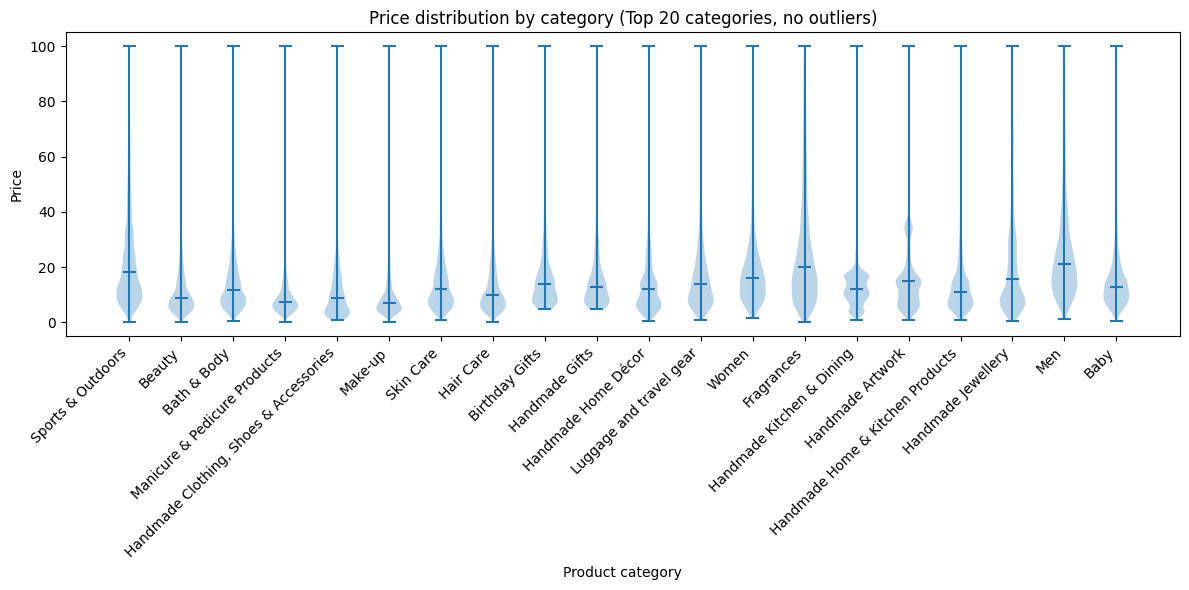

In [43]:
#Violin Plots
top20 = df_no["category"].value_counts().head(20).index

data = [df_no.loc[df_no["category"] == c, "price"] for c in top20] #

plt.figure(figsize=(12,6))
plt.violinplot(data, showmedians=True)
plt.xticks(range(1, len(top20)+1), top20, rotation=45, ha="right")
plt.xlabel("Product category")
plt.ylabel("Price")
plt.title("Price distribution by category (Top 20 categories, no outliers)")
plt.tight_layout()
plt.show()


In [ ]:
#Sin filtrado por categoría
print(df_no.groupby("category")["price"].median().sort_values(ascending=False).head(10))
print("The categories with the highest median price without filters is Desktop PCs")   

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64
The categories with the highest median price is Desktop PCs


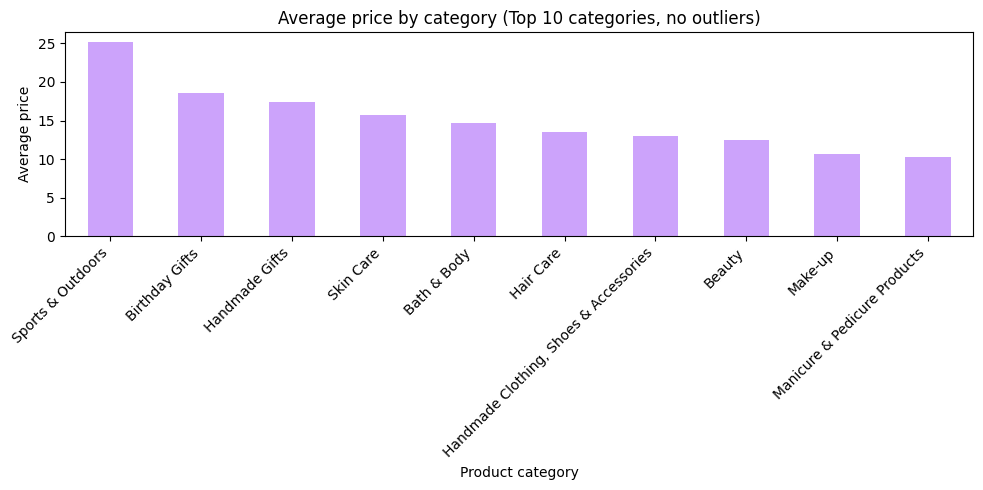

In [48]:
#Bar Charts
top10 = df_no["category"].value_counts().head(10).index

mean_price = (
    df_no[df_no["category"].isin(top10)]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

mean_price.plot(kind="bar", figsize=(10,5), color="#B981FAB9")
plt.xlabel("Product category")
plt.ylabel("Average price")
plt.title("Average price by category (Top 10 categories, no outliers)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [50]:
print(df_no.groupby("category")["price"].mean().sort_values(ascending=False).head(10))
print("The categories with the highest average price without filters is Motherboards")

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64
The categories with the highest average price without filters is Motherboards


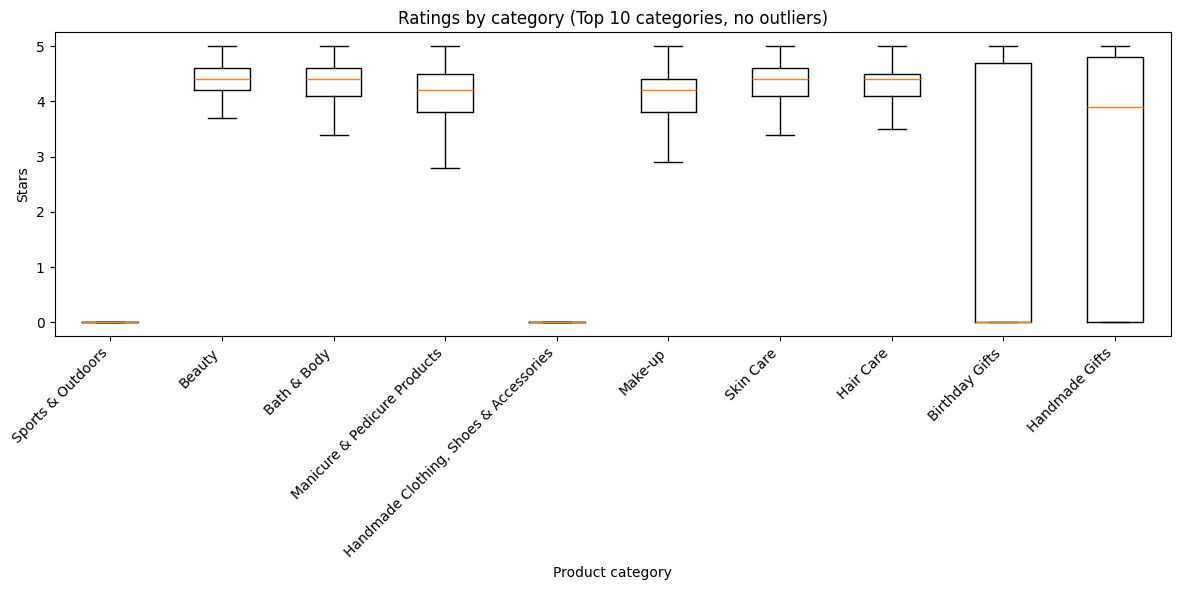

In [51]:
#Box Plots  
df_box = df_no[df_no["category"].isin(top10)]

data_stars = [df_box.loc[df_box["category"] == c, "stars"] for c in top10]

plt.figure(figsize=(12,6))
plt.boxplot(data_stars, showfliers=False)
plt.xticks(range(1, len(top10)+1), top10, rotation=45, ha="right")
plt.xlabel("Product category")
plt.ylabel("Stars")
plt.title("Ratings by category (Top 10 categories, no outliers)")
plt.tight_layout()
plt.show()


In [53]:

print(df_no.groupby("category")["stars"].median().sort_values(ascending=False).head(10))
print("The categories with the highest median rating without filters is Computer Memory")

category
Computer Memory                 4.7
Beer, Wine & Spirits            4.6
Building & Construction Toys    4.6
Office Paper Products           4.6
Kids' Play Figures              4.6
Laptop Accessories              4.6
Hobbies                         4.6
Luxury Food & Drink             4.6
Soft Toys                       4.5
Boxes & Organisers              4.5
Name: stars, dtype: float64
The categories with the highest median rating without filters is Computer Memory


### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?

In [56]:
#Correlation Coefficients
from scipy.stats import pearsonr

pearson_r, pearson_p = pearsonr(df_no["price"], df_no["stars"])
pearson_r, pearson_p
#Interpretation
alpha = 0.05
print(f"P-valor = {pearson_p:.3f}")
if pearson_p < alpha:
    print("Rechazamos la hipótesis nula: existe una correlación significativa entre la puntuación y el precio.")
else:
    print("No rechazamos la hipótesis nula: no existe una correlación significativa entre la puntuación y el precio.")

P-valor = 0.000
Rechazamos la hipótesis nula: existe una correlación significativa entre la puntuación y el precio.


In [ ]:
from scipy.stats import spearmanr

spearman_r, spearman_p = spearmanr(df_no["price"], df_no["stars"])
spearman_r, spearman_p

#Interpretation
alpha = 0.05
print(f"P-valor = {spearman_p:.3f}")
if spearman_p < alpha:
    print("Rechazamos la hipótesis nula: existe una correlación significativa entre la puntuación y el precio.")
else:
    print("No rechazamos la hipótesis nula: no existe una correlación significativa entre la puntuación y el precio.")


P-valor = 0.000
Rechazamos la hipótesis nula: existe una correlación significativa entre la puntuación y el precio.


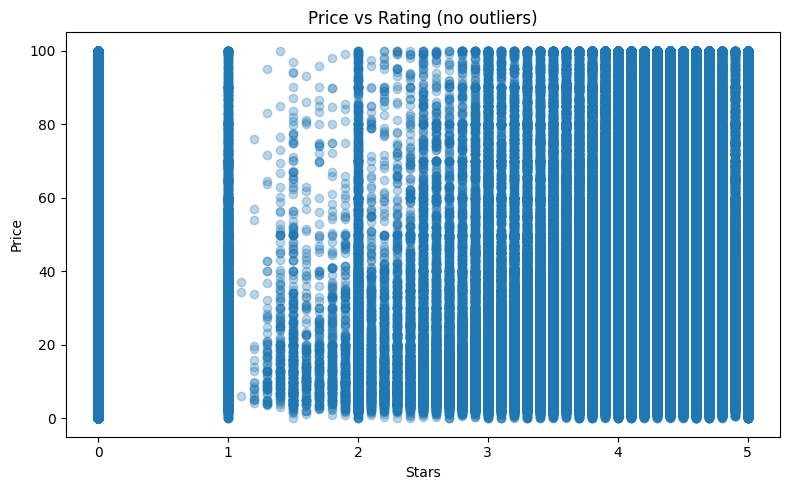

In [ ]:
#Visualization of Correlations

# Scatter Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_no["stars"], df_no["price"], alpha=0.3)
plt.xlabel("Stars")
plt.ylabel("Price")
plt.title("Price vs Rating (no outliers)")
plt.tight_layout()
plt.show()


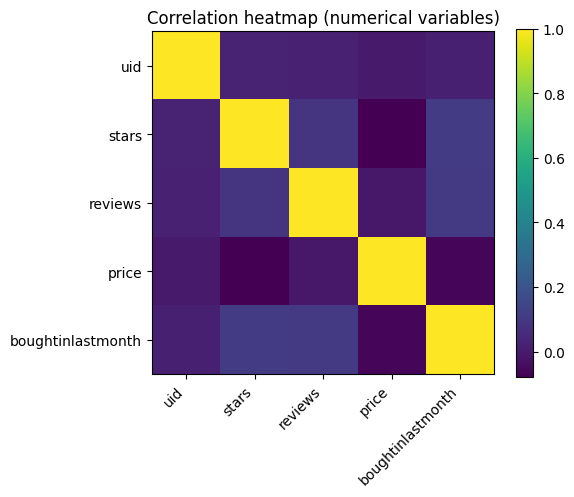

In [63]:
#Heatmap

num_cols = df_no.select_dtypes(include=[np.number])
corr = num_cols.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap (numerical variables)")
plt.tight_layout()
plt.show()


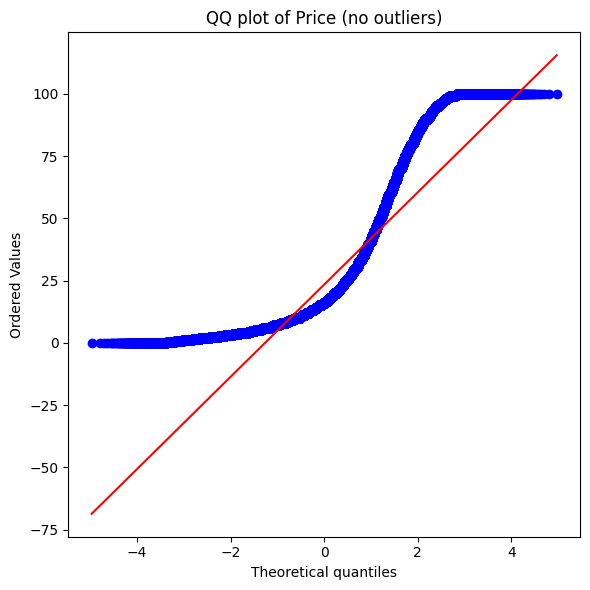

In [64]:
#QQ Plot
from scipy import stats

plt.figure(figsize=(6,6))
stats.probplot(df_no["price"], dist="norm", plot=plt)
plt.title("QQ plot of Price (no outliers)")
plt.tight_layout()
plt.show()


## Executive Summary

---

## Part 1 – Best-seller Status and Product Categories

- Best-seller products represent a **small share** of total products across all categories.
- Some categories show a slightly higher proportion of best-sellers, but overall differences remain limited.
- The Chi-square test indicates a **statistically significant relationship** between product category and best-seller status.
- However, **Cramér’s V reveals a weak association**, suggesting that product category alone has limited explanatory power in determining best-seller status.

---

## Part 2 – Prices and Ratings Across Product Categories

### Product Prices
- Price outliers were removed using the **Interquartile Range (IQR) method** to improve interpretability.
- Clear differences in **price distributions** are observed across product categories.
- Certain categories tend to have **higher median and average prices**, indicating more premium product positioning.
- Despite this, price variability within categories remains high.

### Product Ratings
- Most categories display **high median customer ratings**, typically concentrated between 4 and 5 stars.
- Ratings show limited dispersion, reducing their ability to differentiate clearly between categories.
- Higher-priced categories do not systematically receive higher customer ratings.

---

## Part 3 – Relationship Between Prices and Ratings

- Both Pearson and Spearman correlation coefficients indicate a **weak relationship** between product price and customer rating.
- Scatter plot analysis confirms the absence of a clear trend linking higher prices to better ratings.
- The QQ plot shows that product prices do **not follow a normal distribution**, even after removing outliers.
- These findings suggest that customer ratings are influenced by factors beyond price, such as perceived value, expectations, and product quality.

---

## Overall Business Takeaways

- Product category has a **limited impact** on best-seller performance.
- Pricing strategy alone is unlikely to significantly influence customer ratings.
- Product success on Amazon UK is likely driven by a **combination of factors**, including visibility, reviews, branding, and competitive positioning.
